In [1]:
include("functions.jl")
using Plots, JLD2, LaTeXStrings, FileIO

### Analyzing Single Trajectory

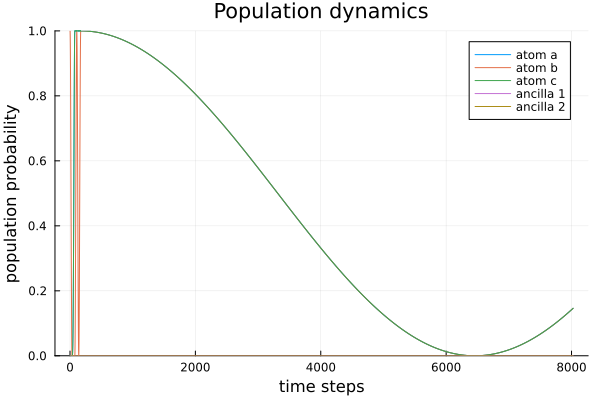

In [4]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/N_atoms=5_γ_dephase=0.0_Ntraj=1.jld2"

population_data = population_data;
corrected_population_data = corrected_population_data;
ψt_end = ψt_end
ψ_target2 = ψ_target2;

# t1 = tspan1[end]+tspan2[end]+tspan2[end]+tspan3[end]
# t = [0.0:0.1:683.8;]
# t2 = [t[end]:0.1:(t[end]+tspan2[end]);]

plot(population_data[:a],  ylim=[0,1], label="atom a", xlabel="time steps", ylabel="population probability", title="Population dynamics")
plot!(population_data[:b], label="atom b")
plot!(population_data[:c], label="atom c")
plot!(population_data[:a1], label="ancilla 1")
plot!(population_data[:a2], label="ancilla 2")

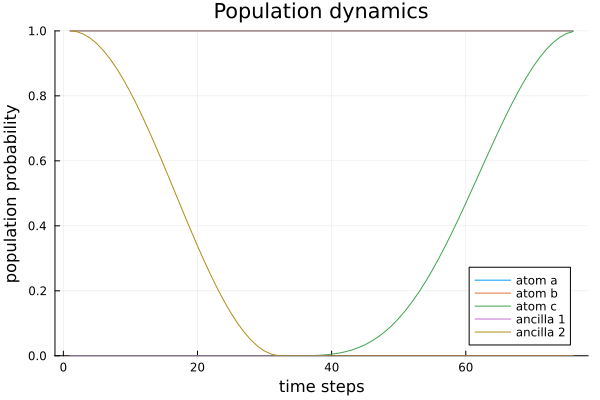

In [16]:
plot(corrected_population_data[:a],  ylim=[0,1], label="atom a", xlabel="time steps", ylabel="population probability", title="Population dynamics")
plot!(corrected_population_data[:b], label="atom b")
plot!(corrected_population_data[:c], label="atom c")
plot!(corrected_population_data[:a1], label="ancilla 1")
plot!(corrected_population_data[:a2], label="ancilla 2")

In [8]:
ψt_end

Ket(dim=243)
  basis: [NLevel(N=3) ⊗ NLevel(N=3) ⊗ NLevel(N=3) ⊗ NLevel(N=3) ⊗ NLevel(N=3)]
 0.0041201394f0 - 0.00615901f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
   0.02071778f0 - 0.030987171f0im
                ⋮
   2.4226922f-5 + 6.05353f-5im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im

In [9]:
ψ_target2

243-element Vector{ComplexF64}:
 0.35355339059327384 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
 0.35355339059327384 + 0.0im
                     ⋮
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im

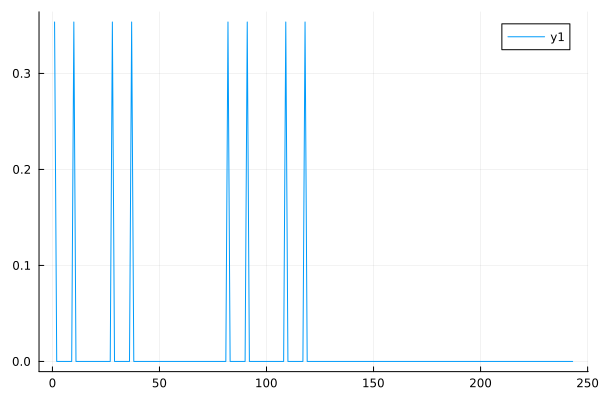

In [4]:
plot(real.(ψ_target2))

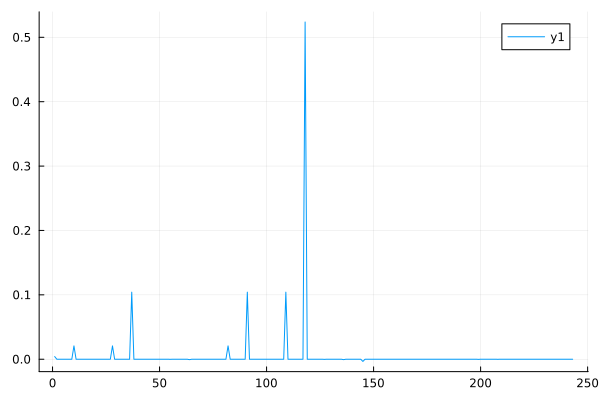

In [6]:
plot(real.(ψt_end.data))

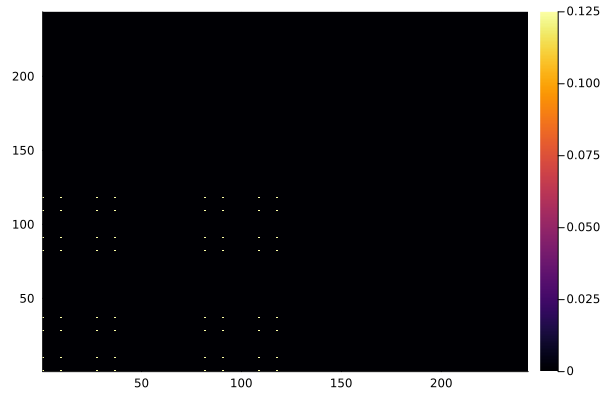

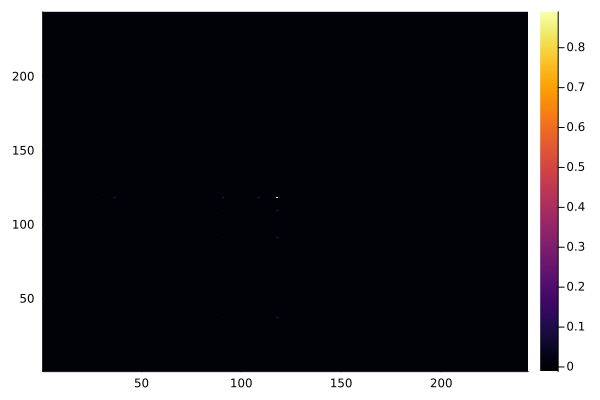

In [7]:
full_basis = CompositeBasis([NLevelBasis(3) for _ in 1:total_qubits]...)
ψ_target = Ket(full_basis, ψ_target2)
ρ_target = ψ_target ⊗ dagger(ψ_target)


ρ_obtained = ψt_end ⊗ dagger(ψt_end)

display(heatmap(real.(ρ_target.data)))
display(heatmap(real.(ρ_obtained.data)))

In [25]:
length(tspan1) + length(tspan2)

957

In [21]:
full_basis = CompositeBasis([NLevelBasis(3) for _ in 1:total_qubits]...)
virtual_z_single_gate = exp(-1im * π/4) * transition(basis, 1, 1) + exp(1im * π/4) * transition(basis, 2, 2) + transition(basis, 3, 3)

ψtest = virtual_z_full * Ket(full_basis, reduce(kron,[b,b,b,a,a]))
# println("only first-three signs flipped? ", real(expect(n_g1_k,ψtest)))

Ket(dim=243)
  basis: [NLevel(N=3) ⊗ NLevel(N=3) ⊗ NLevel(N=3) ⊗ NLevel(N=3) ⊗ NLevel(N=3)]
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
     ⋮
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im

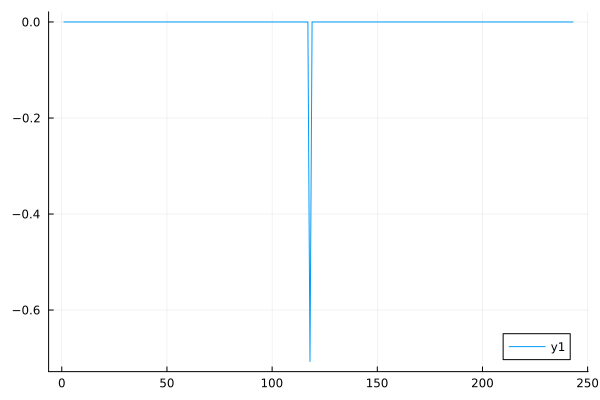

In [23]:
plot(real.(ψtest.data))

### Average Trajectory analysis

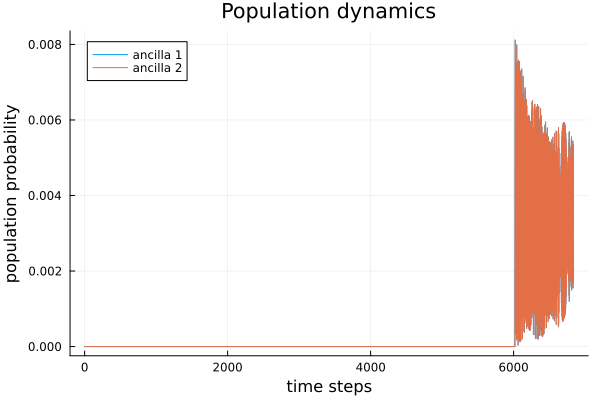

In [4]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/N_atoms=5_γ_dephase=1e-4_Ntraj=1000_avg.jld2"

avg_population_data = avg_population_data;
avg_corrected_population_data = avg_corrected_population_data;

# plot(avg_population_data[:a],  ylim=[0,1], label="atom a", xlabel="time steps", ylabel="population probability", title="Population dynamics")
# plot!(avg_population_data[:b], label="atom b")
# plot!(avg_population_data[:c], label="atom c")
plot(avg_population_data[:a1], label="ancilla 1", xlabel="time steps", ylabel="population probability", title="Population dynamics")
plot!(avg_population_data[:a2], label="ancilla 2")

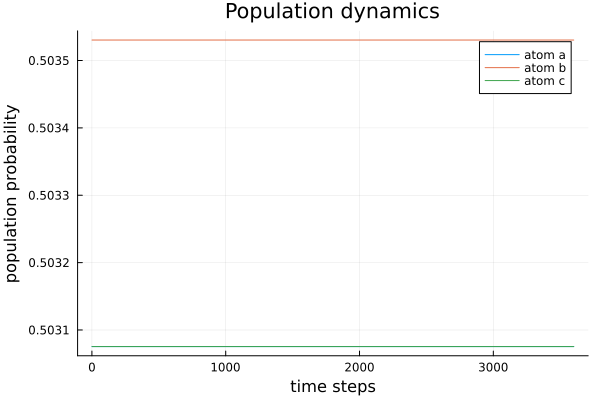

In [6]:
plot(avg_corrected_population_data[:a], label="atom a", xlabel="time steps", ylabel="population probability", title="Population dynamics")
plot!(avg_corrected_population_data[:b], label="atom b")
plot!(avg_corrected_population_data[:c], label="atom c")
# plot!(avg_corrected_population_data[:a1], label="ancilla 1")
# plot!(avg_corrected_population_data[:a2], label="ancilla 2")